In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

# ------ NATURAL UNIT CONVERSIONS --------
cm_to_GeVinv = 5.07e13
g_to_GeV = 5.62e23
c_light = 3e10

# ------ CONSTANTS --------
rho_chi = 0.3 * (1 / cm_to_GeVinv**3)   # GeV^4
R_sun = 7e10 * cm_to_GeVinv             # GeV^-1

v_max = 600e5 / c_light
v0 = 220e5 / c_light

rho_c = 150 * g_to_GeV / (cm_to_GeVinv**3)  # GeV^4
rT = 0.1 * R_sun

# ------------------ LOAD SOLAR MODEL ------------------
clean_rows = []

with open("bp2000_standard.txt") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 12:
            try:
                clean_rows.append([float(x) for x in parts])
            except:
                pass

data = np.array(clean_rows)
print("Shape of clean data:", data.shape)

# ---------- Extract columns ----------
R_frac  = data[:,1]
rho_tab_cgs = data[:,3]
XH_tab  = data[:,6]
YHe_tab = data[:,7]

# ---------- Radius ----------
r_tab = R_frac * R_sun

# ---------- Density (natural units) ----------
rho_tab = rho_tab_cgs * g_to_GeV / (cm_to_GeVinv**3)

# ---------- CGS quantities (for gravity only) ----------
r_cm = r_tab / cm_to_GeVinv
rho_cgs = rho_tab_cgs

# ---------- Mass profile (CGS) ----------
def compute_M_of_r(r_array, rho_array):
    M = np.zeros_like(r_array)
    for i in range(1, len(r_array)):
        dr = r_array[i] - r_array[i-1]
        rho_avg = 0.5 * (rho_array[i] + rho_array[i-1])
        r_avg = 0.5 * (r_array[i] + r_array[i-1])
        shell = 4*np.pi * rho_avg * r_avg**2 * dr
        M[i] = M[i-1] + shell
    return M

M_tab_cgs = compute_M_of_r(r_cm, rho_cgs)

# ---------- Escape velocity (CGS → dimensionless) ----------
G_cgs = 6.674e-8  # cm^3 g^-1 s^-2

vesc_tab = np.sqrt(2 * G_cgs * M_tab_cgs / np.maximum(r_cm, 1e-10))
vesc_tab[0] = vesc_tab[1]

# Convert to natural units (v/c)
vesc_tab = vesc_tab / c_light

# ---------- Convert mass to natural units ----------
M_tab = M_tab_cgs * g_to_GeV  # GeV

# Solar mass (important for orbital physics)
M_sun = M_tab[-1]

# Newton constant in natural units
G = 6.708e-39  # GeV^-2

# ---------- Metallicity ----------
Z_tab = np.clip(1 - XH_tab - YHe_tab, 0.0, 1.0)

f_Fe = 0.06
f_P  = 5e-5

XFe_tab = f_Fe * Z_tab
XP_tab  = f_P * Z_tab

# ---------- FAST INTERPOLATION ----------
vesc_fast = lambda r: np.interp(r, r_tab, vesc_tab)
rho_fast  = lambda r: np.interp(r, r_tab, rho_tab)
XH_fast   = lambda r: np.interp(r, r_tab, XH_tab)
XFe_fast  = lambda r: np.interp(r, r_tab, XFe_tab)
XP_fast   = lambda r: np.interp(r, r_tab, XP_tab)

Shape of clean data: (876, 12)


In [2]:
m_v = 246.2  # GeV
c_val = 1e-3 / (m_v**2)
# ------------------ VELOCITY DISTRIBUTION ------------------
v_sun = 232e5 / c_light  # natural units

def f_raw(u):
    return (u/(np.sqrt(np.pi)*v0*v_sun)) * (
        np.exp(-(u - v_sun)**2 / v0**2) -
        np.exp(-(u + v_sun)**2 / v0**2)
    )

u_norm = np.logspace(-6, np.log10(v_max), 500)

norm = np.trapezoid(f_raw(u_norm), u_norm) + 1e-30

def f(u):
    val = f_raw(u)/norm
    return np.maximum(val, 0.0)

# ------------------ DM DISTRIBUTION ------------------
def g_th(r, r_chi):
    return np.exp(-r**2 / r_chi**2)

# ------------------ ORBIT-AVERAGED DISTRIBUTION ------------------
def g_orb(r, a):
    g = np.zeros_like(r)

    valid = (r > 1e-8*R_sun) & (r < 1.999*a)

    Mloc = np.interp(r[valid], r_tab, M_tab)

    vr2 = 2 * G * Mloc * (1/r[valid] - 1/(2*a))

    vr2 = np.maximum(vr2, 1e-40)

    vr = np.sqrt(vr2)

    g[valid] = 1.0 / (4*np.pi * r[valid]**2 * vr)

    # remove pathological spikes
    g = np.clip(g, 0, 1e60)

    return g

# ------------------ THERMAL RADIUS ------------------
kB = 8.617e-14      # GeV/K
Tc = 1.57e7         # K (solar core temperature)

def thermal_radius(mchi):
    rchi = np.sqrt(
        (3 * kB * Tc) /
        (2 * np.pi * G * rho_c * mchi)
    )

    return rchi

# ------------------ THERMALIZATION PARAMETER ------------------
def eta_from_tth(t_th):

    if not np.isfinite(t_th):
        return 0.0

    if t_th <= 0:
        return 1.0

    eta = 1.0 - np.exp(-t_sun / t_th)

    return np.clip(eta, 0.0, 1.0)
    
def normalize_g(r, g):
    norm = np.trapezoid(4*np.pi*r**2 * g, r)
    return g / max(norm, 1e-30)
    
# ------------------ ANNIHILATION COEFFICIENT ------------------
sigma_v_cm = 3e-26 # thermal relic annihilation cross section (cm^3/s)
sigma_v = sigma_v_cm * (cm_to_GeVinv**3) / (1.52e24)  # convert to natural units (GeV^-2)

def compute_CA(r, g):
    integrand = g**2 * 4*np.pi*r**2
    CA = sigma_v * np.trapezoid(integrand, r)
    return max(CA, 1e-300)

# ------------------ ESCAPE VELOCITY ------------------
def w(u, r):
    return np.sqrt(u**2 + vesc_fast(r)**2)

# ------------------ REDUCED MASS ------------------
def mu(mchi, mT):
    return (mchi*mT)/(mchi + mT)

# ------------------ ENERGY LIMITS ------------------
def Emax(mchi, mT, u, r):
    muT = mu(mchi, mT)
    return 2*(muT**2)*(w(u,r)**2)/mT

def Emin(mchi, u, r):
    return 0.5 * mchi * u**2
    
# ------------------ NUMBER DENSITY ------------------
def nT(r, element):
    rho = rho_fast(r)

    if rho <= 0:
        return 0.0

    if element == "H":
        X = XH_fast(r)
        mT = 0.931

    elif element == "Fe":
        X = XFe_fast(r)
        mT = 56*0.931

    elif element == "P":
        X = XP_fast(r)
        mT = 31*0.931

    return (X * rho) / mT

# ------------------ NUMBER OF PARTICLES ------------------
t_sun = 4.5e9 * 3.15e7 * 1.52e24  # GeV^-1

def compute_N(C, CA):
    return np.sqrt(C/CA) * np.tanh(np.sqrt(C*CA) * t_sun)

# ------------------ ANNIHILATION RATE ------------------
def compute_GammaA(CA, N):
    Gamma_nat = 0.5 * CA * N**2
    return Gamma_nat * 1.52e24  # GeV -> s^-1

# ------------------ Dimensionless parameter b ------------------
def b_param(A):
    return np.sqrt(41.467 / (45*A**(-1/3) - 25*A**(-2/3)))

# ------------------ NUCLEAR RESPONSE ------------------
def W_total(q, element, op):

    # ---------- HYDROGEN ----------
    if element == "H":
        WM = 0.0397887
        WS1 = 0.0795775
        WS2 = 0.0397887

        if op == "O4":
            return {
                "Sigma_p": {
                    "00": WS1,
                    "11": WS1,
                    "10": WS1,
                    "01": WS1
                 },
                "Sigma_pp": {
                    "00": WS2,
                    "11": WS2,
                    "10": WS2,
                    "01": WS2
                 }
            }

        elif op == "O8":
            return {"00":WM, "11":WM, "10":WM, "01":WM}

        elif op == "O15":
            # Hydrogen contributes through Σ′
            WS1 = 0.0795775   # Σ′
            return {
                "Sigma_p": {
                    "00": WS1,
                    "11": WS1,
                    "10": WS1,
                    "01": WS1
                }
            }

    # ---------- IRON ----------
    elif element == "Fe":
        A = 56
        b = b_param(A)
        y = (q * b / 2)**2
        expf = np.exp(-2*y)

        # ---- M ----
        WM00 = expf*(62.3888 -160.428*y +152.644*y**2 -67.2779*y**3 +14.478*y**4 -1.43665*y**5 +0.0525291*y**6)
        WM11 = expf*(0.318309 -1.27323*y +1.99188*y**2 -1.54562*y**3 +0.622264*y**4 -0.122277*y**5 +0.00921525*y**6)
        WM10 = expf*(-4.45633 +14.6422*y -18.2579*y**2 +10.8919*y**3 -3.2296*y**4 +0.446836*y**5 -0.0220016*y**6)
        WM01 = WM10

        # ---- Φ'' ----
        Wphi00 = expf*(4.22872 -6.76595*y +3.79067*y**2 -0.867433*y**3 +0.069506*y**4)
        Wphi11 = expf*(0.143378 -0.229404*y +0.144606*y**2 -0.0422756*y**3 +0.00486921*y**4)
        Wphi10 = expf*(-0.778655 +1.24585*y -0.741661*y**2 +0.194658*y**3 -0.0183967*y**4)
        Wphi01 = Wphi10

        if op == "O4":
            return {"00":0, "11":0, "10":0, "01":0}

        elif op == "O8":
            return {"00":WM00, "11":WM11, "10":WM10, "01":WM01}

        elif op == "O15":
            return {
                "Phi_pp": {
                    "00": Wphi00,
                    "11": Wphi11,
                    "10": Wphi10,
                    "01": Wphi01
                }
            }

    # ---------- PHOSPHORUS ----------
    elif element == "P":
        A = 31
        b = b_param(A)
        y = (q * b / 2)**2
        expf = np.exp(-2*y)

        WM00 = (A**2) * expf
        WM11 = expf      
        # include interference 
        WM10 = A * expf
        WM01 = WM10

        if op == "O4":
            return {"00":0, "11":0, "10":0, "01":0}

        elif op == "O8":
            return {"00":WM00, "11":WM11, "10":WM10, "01":WM01}

        elif op == "O15":
            return {"Phi_pp": {"00":0,"11":0,"10":0,"01":0}}

    return {"00":0, "11":0, "10":0, "01":0}

# ------------------ WIMP RESPONSE ------------------
def R_total(v, q, op, mchi, mT, c0, c1):
    muT = mu(mchi, mT)
    vT2 = max(v**2 - q**2/(4*muT**2), 0.0)
    mN = 0.939
    q2 = q**2 / mN**2
    #q2 = min(q2, 1.0)

    if op == "O4":
        factor = 1/16.0
        return {
            "00": factor * c0*c0,
            "11": factor * c1*c1,
            "01": factor * c0*c1,
            "10": factor * c1*c0}

    elif op == "O8":
        factor = (1/4.0) * vT2
        return {
            "00": factor * c0*c0,
            "11": factor * c1*c1,
            "01": factor * c0*c1,
            "10": factor * c1*c0}

    elif op == "O15":
        factor_phi = (1/16.0) * ((q2)**2)
        factor_sigma = (1/16.0) * ((q2)**2) * (vT2/2.0)   # Σ′ piece
        
        return {
            "Phi_pp": {
                "00": factor_phi * c0*c0,
                "11": factor_phi * c1*c1,
                "01": factor_phi * c0*c1,
                "10": factor_phi * c1*c0
             }, 
            "Sigma_p": {
                "00": factor_sigma * c0*c0,
                "11": factor_sigma * c1*c1,
                "01": factor_sigma * c0*c1,
                "10": factor_sigma * c1*c0
            }
        }
        

    return {"00":0, "11":0, "01":0, "10":0}
    
# ------------------ CROSS SECTION ------------------
def dsdER_orbital(mchi, mT, ER, w_val, r, op, element):

    v = w_val   # directly use w, NOT recomputed

    if v**2 < 1e-12:
        return 0.0

    q = np.sqrt(2*mT*ER)
    JT = 0.5 if element in ["H","P"] else 0.0

    W = W_total(q, element, op)
    R = R_total(v, q, op, mchi, mT, c_val, 0.0)

    if op == "O4":
        if element != "H":
            return 0.0
        total = (
            R["00"] * (W["Sigma_p"]["00"] + W["Sigma_pp"]["00"]) +
            R["11"] * (W["Sigma_p"]["11"] + W["Sigma_pp"]["11"]) +
            R["01"] * (W["Sigma_p"]["01"] + W["Sigma_pp"]["01"]) +
            R["10"] * (W["Sigma_p"]["10"] + W["Sigma_pp"]["10"])
        )

    elif op == "O8":
        total = (
            R["00"] * W["00"] +
            R["11"] * W["11"] +
            R["01"] * W["01"] +
            R["10"] * W["10"]
        )

    elif op == "O15":
        if element == "Fe":
            total = (
                R["Phi_pp"]["00"] * W["Phi_pp"]["00"] +
                R["Phi_pp"]["11"] * W["Phi_pp"]["11"] +
                R["Phi_pp"]["01"] * W["Phi_pp"]["01"] +
                R["Phi_pp"]["10"] * W["Phi_pp"]["10"]
            )
        elif element == "H":
            total = (
                R["Sigma_p"]["00"] * W["Sigma_p"]["00"] +
                R["Sigma_p"]["11"] * W["Sigma_p"]["11"] +
                R["Sigma_p"]["01"] * W["Sigma_p"]["01"] +
                R["Sigma_p"]["10"] * W["Sigma_p"]["10"]
            )
        else:
            return 0.0
    else:
        return 0.0

    return (2*mT*total)/((2*JT+1)*v**2)

# ------------------ compute_a0_single ------------------
def compute_a0_single(r, ER, mchi, w_loc):

    vf2 = w_loc**2 - 2*ER/mchi

    if vf2 <= 0:
        return None

    epsilon = vf2/2 - G*M_sun/r

    if epsilon >= 0:
        return None

    a0 = -G*M_sun/(2*epsilon)

    if a0 > 1e3 * R_sun:
        return None

    if not np.isfinite(a0) or a0 <= 0:
        return None

    return a0

print("c_val =", c_val)
print("c_val^2 =", c_val**2)
print("rchi =", thermal_radius(100))
print("Rsun =", R_sun)

c_val = 1.6497719025367554e-08
c_val^2 = 2.721747330399746e-16
rchi = 3.85833729218365e+22
Rsun = 3.549e+24


In [3]:
# DETERMINISTIC a0 COMPUTATION
ops = ["O4","O8","O15"]
mchi_vals = np.logspace(2,5,30)

results_a0 = {op:[] for op in ops}
results_C = {op:[] for op in ops}

# integration grids
r_grid = np.logspace(
    np.log10(1e-4*R_sun),
    np.log10(R_sun),
    60
)

u_grid = np.logspace(
    np.log10(1e-5),
    np.log10(v_max), 50)

elements = ["H","Fe","P"]

mT_dict = {
    "H":0.931,
    "Fe":56*0.931,
    "P":31*0.931
}

dr = np.gradient(r_grid)

du = np.diff(u_grid)
du = np.append(du, du[-1])

for op in ops:

    print(f"\nRunning {op}")

    for mchi in mchi_vals:

        numerator = 0.0
        denominator = 0.0
        capture_total = 0.0

        for ir, r in enumerate(r_grid):
            vesc_r = vesc_fast(r)

            for iu, u in enumerate(u_grid):

                fu = f(u) / max(u, 1e-30)

                if fu <= 0:
                    continue

                for el in elements:

                    mT = mT_dict[el]

                    nt = nT(r,el)

                    if nt <= 0:
                        continue

                    w_loc = np.sqrt(u**2 + vesc_r**2)

                    Emin_val = Emin(mchi,u,r)
                    Emax_val = Emax(mchi,mT,u,r)

                    if Emax_val <= 1.001 * Emin_val:
                        continue

                    if op == "O15":
                        NER = 60
                    else:
                        NER = 35

                    # logarithmic recoil grid
                    ER_grid = np.logspace(
                        np.log10(max(Emin_val,1e-20)),
                        np.log10(Emax_val), NER)
                    
                    dER = np.gradient(ER_grid)

                    for iER, ER in enumerate(ER_grid):

                        ds = dsdER_orbital(
                            mchi,mT,ER,w_loc,r,op,el
                        )

                        if ds <= 0:
                            continue

                        # capture condition
                        vf2 = w_loc**2 - 2*ER/mchi

                        if vf2 >= vesc_r**2:
                            continue

                        a0 = compute_a0_single(
                            r,ER,mchi,w_loc
                        )

                        if a0 is None:
                            continue

                        # differential capture weight
                        dC = (4*np.pi * r**2 *
                              fu * w_loc**2 *
                              (rho_chi/mchi) *
                              nt * ds)

                        weight = dC * dr[ir] * du[iu] * dER[iER]
                        
                        capture_total += weight

                        numerator += a0 * weight
                        denominator += weight

        if denominator > 1e-300:

            a0_avg = numerator / denominator

        else:
            a0_avg = np.nan

        #print(op, mchi, "a0/Rsun =", a0_avg / R_sun)

        results_a0[op].append(a0_avg)
        results_C[op].append(capture_total)

#----------- CAPTURE RATES -------------
print("\n===== CAPTURE RATES =====")

for op in ops:

    print(f"\n{op}")

    for m in [100,1000,10000,100000]:

        idx = np.argmin(np.abs(mchi_vals-m))

        C_natural_unit = results_C[op][idx]          # GeV
        C_sec = C_natural_unit * 1.52e24             # s^-1

        print(
            f"mχ = {mchi_vals[idx]:.2f} GeV"
            f"   C_natural_unit = {C_natural_unit:.3e} GeV"
            f"   C = {C_sec:.3e} s^-1"
        )
        
#----------- SAVE data ------------- 
np.save("a0_data.npy", results_a0)
np.save("mchi_vals.npy", mchi_vals)
np.save("capture_data.npy", results_C)

print("✅ deterministic a0 computation done")


Running O4

Running O8

Running O15

===== CAPTURE RATES =====

O4
mχ = 100.00 GeV   C_natural_unit = 6.619e-08 GeV   C = 1.006e+17 s^-1
mχ = 1082.64 GeV   C_natural_unit = 5.884e-10 GeV   C = 8.944e+14 s^-1
mχ = 9236.71 GeV   C_natural_unit = 7.684e-12 GeV   C = 1.168e+13 s^-1
mχ = 100000.00 GeV   C_natural_unit = 3.255e-14 GeV   C = 4.947e+10 s^-1

O8
mχ = 100.00 GeV   C_natural_unit = 3.343e-10 GeV   C = 5.081e+14 s^-1
mχ = 1082.64 GeV   C_natural_unit = 2.172e-11 GeV   C = 3.301e+13 s^-1
mχ = 9236.71 GeV   C_natural_unit = 3.676e-13 GeV   C = 5.588e+11 s^-1
mχ = 100000.00 GeV   C_natural_unit = 3.152e-15 GeV   C = 4.791e+09 s^-1

O15
mχ = 100.00 GeV   C_natural_unit = 1.263e-09 GeV   C = 1.920e+15 s^-1
mχ = 1082.64 GeV   C_natural_unit = 5.333e-10 GeV   C = 8.106e+14 s^-1
mχ = 9236.71 GeV   C_natural_unit = 1.087e-11 GeV   C = 1.652e+13 s^-1
mχ = 100000.00 GeV   C_natural_unit = 9.516e-14 GeV   C = 1.446e+11 s^-1
✅ deterministic a0 computation done


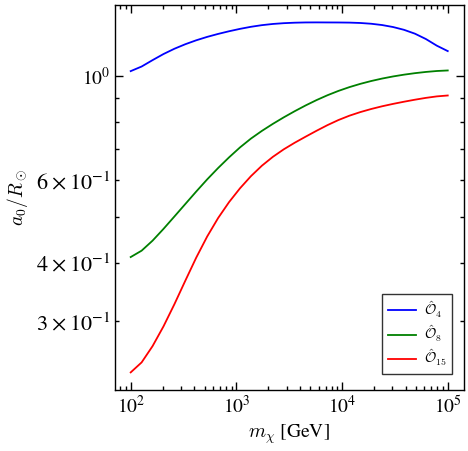

In [5]:
# ------------------ a0 PLOT ------------------
fig= plt.subplots(figsize=(4.5,5))
plt.style.use(['science','notebook','no-latex'])

from scipy.ndimage import gaussian_filter1d

for op in ops:

    a_arr = np.array(results_a0[op], dtype=float)

    valid = (
        np.isfinite(a_arr)
        & (a_arr > 0)
    )

    if np.sum(valid) < 3:
        continue

    a_plot = a_arr[valid] / R_sun

    a_smooth = gaussian_filter1d(
        np.log10(a_plot),
        sigma=1.0
    )

    a_smooth = 10**a_smooth

    if op == "O4":
        color = "blue"

    elif op == "O8":
        color = "green"

    else:
        color = "red"

    plt.loglog(
        mchi_vals[valid],
        a_smooth,
        linewidth=1.3,
        color=color,
        label=rf"$\hat{{\mathcal{{O}}}}_{{{op[1:]}}}$"
    )

plt.xlabel(
    r"$m_\chi$ [GeV]",
    fontsize=14
)

plt.ylabel(
    r"$a_0/R_\odot$",
    fontsize=14
)

#plt.title(r"Average Initial Semi-Major Axis",fontsize=14)

plt.legend(
    loc='upper right',
    bbox_to_anchor=(0.98,0.26),
    fontsize=10,          # smaller text
    frameon=True,
    edgecolor='black',
    fancybox=False,
    borderpad=0.4,        # padding inside box
    labelspacing=0.3,     # spacing between rows
    handlelength=2.0,     # line length
    handletextpad=0.6,    # space between line and text
    borderaxespad=0.3
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig(
    "a0_vs_mchi.pdf",
    bbox_inches="tight"
)
plt.show()

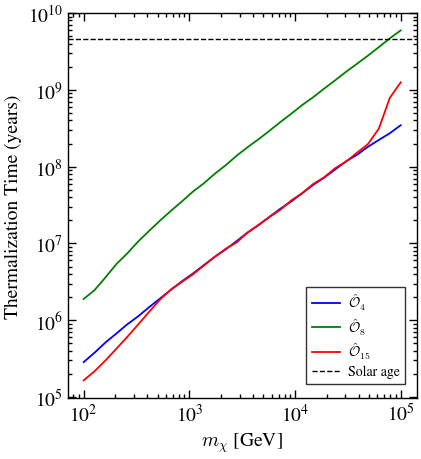

In [12]:
results_a0 = np.load("a0_data.npy", allow_pickle=True).item()
mchi_vals = np.load("mchi_vals.npy")
mchi_vals_delta = np.logspace(2, 5, 35)
ops = ["O4", "O8", "O15"]

# ------------------ ΔE_orb(a) ------------------
def delta_E_orb(a, mchi, op):
    mT_dict = {"H":0.931, "Fe":56*0.931, "P":31*0.931}
    r_min = 1e-5 * R_sun
    r_max = max(min(a, R_sun), 1.1*r_min)

    if op == "O15":
        Nr = 60
    else:
        Nr = 40

    r_vals = np.logspace(np.log10(r_min), np.log10(r_max), Nr)

    integrand_r = []
    r_used = []

    for r in r_vals:

        vr2 = 2*G*M_sun*(1/r - 1/a)
        
        if vr2 <= 0:
            continue

        vr = np.sqrt(vr2)
        v = np.sqrt(2*G*M_sun*(1/r - 1/(2*a)))
        w_loc = v
        
        shell = 0.0

        for el in ["H", "Fe", "P"]:

            n_target = nT(r, el)
            mT = mT_dict[el]
            
            Emax_val = 2*(mu(mchi, mT)**2)*(w_loc**2)/mT
            
            if Emax_val <= 0:
                continue

            ER_low = max(1e-20, Emax_val*1e-6)
            
            if Emax_val <= ER_low:
                continue

            if op == "O15":
                NER = 60
            else:
                NER = 35

            ER_vals = np.logspace(
                np.log10(ER_low),
                np.log10(Emax_val),
                NER)

            # -------- CORRECT ER INTEGRATION --------
            ER_integrand = []

            for ER in ER_vals:
                ds = dsdER_orbital(mchi, mT, ER, w_loc, r, op, el)
                
                if ds <= 0:
                    ER_integrand.append(0.0)
                else:
                    ER_integrand.append(ER * ds)

            ER_int = np.trapezoid(ER_integrand, ER_vals)

            shell += n_target * ER_int

        term = (v / max(vr, 1e-10)) * shell
        integrand_r.append(term)
        r_used.append(r)

    # -------- CORRECT r-INTEGRATION --------
    if len(integrand_r) == 0:
            return 0.0
        
    val = np.trapezoid(integrand_r, r_used)

    # numerical safety
    if not np.isfinite(val):
        return 0.0

    return val

a_grid = np.logspace(-4, 0, 130) * R_sun
delta_tables = {}

for m in mchi_vals_delta:
    delta_tables[m] = {}
    
    for op in ops:
        delta_tables[m][op] = []
        
        for a in a_grid:
            val = delta_E_orb(a, m, op)
            delta_tables[m][op].append(val)

        # smooth AFTER full table is built
        #from scipy.ndimage import gaussian_filter1d
        #delta_tables[m][op] = gaussian_filter1d(delta_tables[m][op], sigma=1.2)

def delta_interp(a, m, op):

    m_grid = np.array(sorted(delta_tables.keys()))

    # interpolate in a first for all m
    vals = np.array([
        np.interp(a, a_grid, delta_tables[m_i][op])
        for m_i in m_grid])

    # then interpolate in m
    logm_grid = np.log10(m_grid)
    val = np.interp(np.log10(m), logm_grid, vals)

    return max(val, 0.0)

# ------------------ ANALYTIC THERMALIZATION TIME ------------------
def thermalization_time(a0, mchi, op):

    if not np.isfinite(a0) or a0 <= 0:
        return np.nan

    rchi = thermal_radius(mchi)

    if a0 <= rchi:
        return 0.0

    a_vals = np.logspace(
        np.log10(rchi),
        np.log10(a0),
        120
    )

    integrand = []
    a_used = []

    for a in a_vals:
        dEorb = delta_interp(a, mchi, op)

        if dEorb <= 0:
            continue

        integrand.append(
            1.0 / (np.sqrt(a) * dEorb)
        )
        
        a_used.append(a)

    integrand = np.array(integrand)

    if len(integrand) < 5:
        return np.nan

    integral = np.trapezoid(
        integrand,
        a_used
    )

    tth = (
        np.pi
        * mchi
        * np.sqrt(G * M_sun)
        * integral
    )

    if not np.isfinite(tth):
        return np.nan
            
    if tth < 0:
        return np.nan

    return tth

# ------------------ EVOLUTION MAIN ------------------
results_tth = {op: [] for op in ops}

for op in ops:    
    for i, m in enumerate(mchi_vals):

        a0 = results_a0[op][i]

        if not np.isfinite(a0) or a0 <= 0:

            results_tth[op].append(np.nan)
            continue

        t_th = thermalization_time(a0, m, op)
        #print(op, m, t_th/(3.15e7*1.52e24))

        results_tth[op].append(t_th)

# -------- Save thermalization time ------------ 
np.save("thermalization_time.npy", results_tth)

# --------- thermalization time (plot) ------------
fig, ax = plt.subplots(figsize=(4.5,5))
plt.style.use(['science','notebook','no-latex'])

styles = {
    "O4":  dict(color='blue',   ls='-'),
    "O8":  dict(color='green',  ls='-'),
    "O15": dict(color='red', ls='-')
}

for op in ops:

    t_arr = np.array(
        results_tth[op],
        dtype=float
    )

    valid = (
        np.isfinite(t_arr)
        & (t_arr > 0)
    )

    ax.loglog(
        mchi_vals[valid],
        t_arr[valid] /
        (3.15e7 * 1.52e24),
        linewidth=1.3,
        label=rf"$\hat{{\mathcal{{O}}}}_{{{op[1:]}}}$",
        **styles[op]
    )

ax.axhline(
    4.6e9,
    color='black',
    ls='--',
    lw=1.0,
    label='Solar age')
ax.set_xlabel(r"$m_\chi$ [GeV]", fontsize=14)
ax.set_ylabel("Thermalization Time (years)", fontsize=14)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(0.98,0.3),
    fontsize=10,          # smaller text
    frameon=True,
    edgecolor='black',
    fancybox=False,
    borderpad=0.4,        # padding inside box
    labelspacing=0.3,     # spacing between rows
    handlelength=2.0,     # line length
    handletextpad=0.6,    # space between line and text
    borderaxespad=0.3
)

ax.tick_params(
    axis='both',
    which='both',
    labelsize=14
)

fig.savefig(
    "thtime_vs_mchi.pdf",
    bbox_inches="tight"
)
plt.show()

In [13]:
# ------------------ print THERMALIZATION TIMES ------------------
print("\n===== THERMALIZATION TIMES =====")

for op in ops:

    print(f"\n{op}")

    for m in [100,1000,10000,100000]:

        idx = np.argmin(np.abs(mchi_vals-m))

        t_years = (
            results_tth[op][idx]
            /(3.15e7*1.52e24)
        )

        print(
            f"mχ = {mchi_vals[idx]:.2f} GeV"
            f"   t_th = {t_years:.3e} yr"
        )


===== THERMALIZATION TIMES =====

O4
mχ = 100.00 GeV   t_th = 2.852e+05 yr
mχ = 1082.64 GeV   t_th = 4.066e+06 yr
mχ = 9236.71 GeV   t_th = 3.525e+07 yr
mχ = 100000.00 GeV   t_th = 3.461e+08 yr

O8
mχ = 100.00 GeV   t_th = 1.891e+06 yr
mχ = 1082.64 GeV   t_th = 4.739e+07 yr
mχ = 9236.71 GeV   t_th = 4.901e+08 yr
mχ = 100000.00 GeV   t_th = 5.941e+09 yr

O15
mχ = 100.00 GeV   t_th = 1.649e+05 yr
mχ = 1082.64 GeV   t_th = 3.963e+06 yr
mχ = 9236.71 GeV   t_th = 3.645e+07 yr
mχ = 100000.00 GeV   t_th = 1.252e+09 yr


Running O4
Running O8
Running O15

===== ETA VALUES =====

O4
mχ = 100.00 GeV   η = 1.000000
mχ = 1082.64 GeV   η = 1.000000
mχ = 9236.71 GeV   η = 1.000000
mχ = 100000.00 GeV   η = 0.999998

O8
mχ = 100.00 GeV   η = 1.000000
mχ = 1082.64 GeV   η = 1.000000
mχ = 9236.71 GeV   η = 0.999897
mχ = 100000.00 GeV   η = 0.531136

O15
mχ = 100.00 GeV   η = 1.000000
mχ = 1082.64 GeV   η = 1.000000
mχ = 9236.71 GeV   η = 1.000000
mχ = 100000.00 GeV   η = 0.972509

===== ANNIHILATION RATE VALUES =====

O4
mχ = 100.00 GeV   Γ_A = 4.368e+14 s^-1
mχ = 1082.64 GeV   Γ_A = 1.235e+12 s^-1
mχ = 9236.71 GeV   Γ_A = 5.254e+09 s^-1
mχ = 100000.00 GeV   Γ_A = 3.359e+06 s^-1

O8
mχ = 100.00 GeV   Γ_A = 1.121e+10 s^-1
mχ = 1082.64 GeV   Γ_A = 1.685e+09 s^-1
mχ = 9236.71 GeV   Γ_A = 1.203e+07 s^-1
mχ = 100000.00 GeV   Γ_A = 1.170e+04 s^-1

O15
mχ = 100.00 GeV   Γ_A = 1.600e+11 s^-1
mχ = 1082.64 GeV   Γ_A = 1.014e+12 s^-1
mχ = 9236.71 GeV   Γ_A = 1.051e+10 s^-1
mχ = 100000.00 GeV   Γ_A = 2.735e+07 s^-1


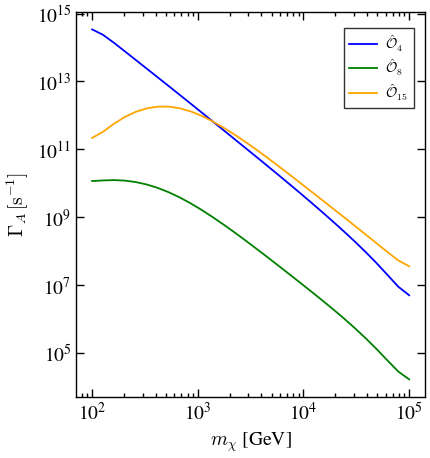

In [16]:
results_a0 = np.load("a0_data.npy", allow_pickle=True).item()
results_C = np.load("capture_data.npy", allow_pickle=True).item()
results_tth = np.load("thermalization_time.npy", allow_pickle=True).item()
Gamma_results = {op: [] for op in ops}
eta_results   = {op: [] for op in ops}

for op in ops:

    print(f"Running {op}")

    for i, mchi in enumerate(mchi_vals):

        a0 = results_a0[op][i]

        if not np.isfinite(a0) or a0 <= 0:
            Gamma_results[op].append(np.nan)
            eta_results[op].append(np.nan)
            continue

        # radial grid
        r_vals = np.logspace(
            np.log10(1e-5 * R_sun),
            np.log10(R_sun),
            300
        )

        # thermal component
        rchi = thermal_radius(mchi)
        gth = g_th(r_vals, rchi)

        # orbital component
        gorb = g_orb(r_vals, a0)

        # normalize separately
        gth = normalize_g(r_vals, gth)
        gorb = normalize_g(r_vals, gorb)

        # thermalization efficiency
        t_th = results_tth[op][i]
        
        if not np.isfinite(t_th):
            Gamma_results[op].append(np.nan)
            eta_results[op].append(np.nan)
            continue

        #print(op, mchi, t_th/(3.15e7*1.52e24))
        
        eta = eta_from_tth(t_th)
        eta_results[op].append(eta)

        # mixed distribution
        g = eta * gth + (1 - eta) * gorb

        # final normalization
        g = normalize_g(r_vals, g)

        # annihilation coefficient
        CA = compute_CA(r_vals, g)
        
        if not np.isfinite(CA) or CA <= 0:
            Gamma_results[op].append(np.nan)
            continue

        # capture rate
        C = results_C[op][i]

        if not np.isfinite(C) or C <= 0:
            Gamma_results[op].append(np.nan)
            continue

        # total particle number
        N = compute_N(C, CA)

        # annihilation rate
        GammaA = compute_GammaA(CA, N)
        #eq_param = np.sqrt(max(C*CA,1e-300)) * t_sun
        #print(f"{op} | mchi={mchi:.2e} GeV | " f"sqrt(CCA)t = {eq_param:.3e}")

        if (
            not np.isfinite(GammaA)
            or GammaA <= 0):

            Gamma_results[op].append(np.nan)

        else:

            Gamma_results[op].append(GammaA)

# ---------- ETA VALUES -----------------
print("\n===== ETA VALUES =====")

for op in ops:
    print(f"\n{op}")
    for m in [100, 1000, 10000, 100000]:

        idx = np.argmin(np.abs(mchi_vals - m))

        eta = eta_results[op][idx]

        print(
            f"mχ = {mchi_vals[idx]:.2f} GeV"
            f"   η = {eta:.6f}"
        )

# ---------- GAMMA_A VALUES -----------------
print("\n===== ANNIHILATION RATE VALUES =====")

for op in ops:

    print(f"\n{op}")

    for m in [100, 1000, 10000, 100000]:

        idx = np.argmin(np.abs(mchi_vals - m))

        GammaA_sec = Gamma_results[op][idx]

        print(
            f"mχ = {mchi_vals[idx]:.2f} GeV"
            f"   Γ_A = {GammaA_sec:.3e} s^-1"
        )
        
#---------- Save annihilation results -----------------
np.save("annihilation_rate.npy", Gamma_results)
np.save("eta_values.npy", eta_results)

#------------ PLOT --------------
fig = plt.subplots(figsize=(4.5,5))
plt.style.use(['science', 'notebook', 'no-latex'])

from scipy.ndimage import gaussian_filter1d

for op in ops:

    Gamma_arr = (np.array(
            Gamma_results[op],
            dtype=float
            )
    )

    valid = (
        np.isfinite(Gamma_arr)
        & (Gamma_arr > 0)
    )

    if np.sum(valid) < 3:
        continue

    if op == "O4":
        color = "blue"

    elif op == "O8":
        color = "green"

    else:
        color = "orange"

    # smooth in log-space
    Gamma_smooth = gaussian_filter1d(
        np.log10(Gamma_arr[valid]),
        sigma=1.0
    )

    Gamma_smooth = 10**Gamma_smooth

    plt.loglog(
        mchi_vals[valid],
        Gamma_smooth,
        linewidth=1.3,
        color=color,
        label=rf"$\hat{{\mathcal{{O}}}}_{{{op[1:]}}}$"
    )

plt.xlabel(
    r"$m_\chi$ [GeV]",
    fontsize=14)

plt.ylabel(
    r"$\Gamma_A \, [\mathrm{s^{-1}}]$",
    fontsize=14)

#plt.title(r"Annihilation Rate as a Function of Dark Matter Mass",fontsize=14)

plt.legend(
    loc='upper right',
    bbox_to_anchor=(0.98,0.97),
    fontsize=10,          # smaller text
    frameon=True,
    edgecolor='black',
    fancybox=False,
    borderpad=0.4,        # padding inside box
    labelspacing=0.3,     # spacing between rows
    handlelength=2.0,     # line length
    handletextpad=0.6,    # space between line and text
    borderaxespad=0.3
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig(
    "GammaA_vs_mass.pdf",
    bbox_inches="tight"
)
plt.show()


===== NEUTRINO FLUX =====

O4
mχ = 100.00 GeV   ΓA = 4.368e+14 s^-1   Φ = 3.106e-13 cm^-2 s^-1
mχ = 1082.64 GeV   ΓA = 1.235e+12 s^-1   Φ = 8.781e-16 cm^-2 s^-1
mχ = 9236.71 GeV   ΓA = 5.254e+09 s^-1   Φ = 3.737e-18 cm^-2 s^-1
mχ = 100000.00 GeV   ΓA = 3.359e+06 s^-1   Φ = 2.389e-21 cm^-2 s^-1

O8
mχ = 100.00 GeV   ΓA = 1.121e+10 s^-1   Φ = 7.969e-18 cm^-2 s^-1
mχ = 1082.64 GeV   ΓA = 1.685e+09 s^-1   Φ = 1.198e-18 cm^-2 s^-1
mχ = 9236.71 GeV   ΓA = 1.203e+07 s^-1   Φ = 8.556e-21 cm^-2 s^-1
mχ = 100000.00 GeV   ΓA = 1.170e+04 s^-1   Φ = 8.320e-24 cm^-2 s^-1

O15
mχ = 100.00 GeV   ΓA = 1.600e+11 s^-1   Φ = 1.138e-16 cm^-2 s^-1
mχ = 1082.64 GeV   ΓA = 1.014e+12 s^-1   Φ = 7.213e-16 cm^-2 s^-1
mχ = 9236.71 GeV   ΓA = 1.051e+10 s^-1   Φ = 7.476e-18 cm^-2 s^-1
mχ = 100000.00 GeV   ΓA = 2.735e+07 s^-1   Φ = 1.945e-20 cm^-2 s^-1


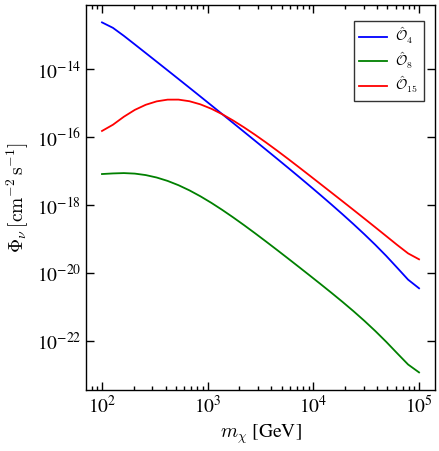

In [17]:
# ------------------ NEUTRINO FLUX ------------------
AU_cm = 1.496e13

Flux_results = {op: [] for op in ops}

for op in ops:

    Gamma_arr = np.array(Gamma_results[op])

    for GammaA_nat in Gamma_arr:

        if (
            not np.isfinite(GammaA_nat)
            or GammaA_nat <= 0
        ):

            Flux_results[op].append(np.nan)

        else:

            GammaA_sec = GammaA_nat

            Phi = (
                2.0 * GammaA_sec
                / (4*np.pi*AU_cm**2)
            )

            Flux_results[op].append(Phi)

# -------- flux values at representative masses ------------
print("\n===== NEUTRINO FLUX =====")

for op in ops:

    print(f"\n{op}")

    for m in [100,1000,10000,100000]:

        idx = np.argmin(np.abs(mchi_vals-m))

        GammaA_sec = (Gamma_results[op][idx])

        Phi = Flux_results[op][idx]

        print(
            f"mχ = {mchi_vals[idx]:.2f} GeV   "
            f"ΓA = {GammaA_sec:.3e} s^-1   "
            f"Φ = {Phi:.3e} cm^-2 s^-1"
        )
        
# ------------------ SAVE ------------------
np.save("neutrino_flux.npy", Flux_results)

# ------------------ PLOT ------------------
fig = plt.subplots(figsize=(4.5,5))
plt.style.use(['science','notebook','no-latex'])

from scipy.ndimage import gaussian_filter1d

for op in ops:

    Flux_arr = np.array(
        Flux_results[op],
        dtype=float
    )

    valid = (
        np.isfinite(Flux_arr)
        & (Flux_arr > 0)
    )

    if np.sum(valid) < 3:
        continue

    if op == "O4":
        color = "blue"

    elif op == "O8":
        color = "green"

    else:
        color = "red"

    Flux_smooth = gaussian_filter1d(
        np.log10(Flux_arr[valid]),
        sigma=1.0
    )

    Flux_smooth = 10**Flux_smooth

    plt.loglog(
        mchi_vals[valid],
        Flux_smooth,
        linewidth=1.3,
        color=color,
        label=rf"$\hat{{\mathcal{{O}}}}_{{{op[1:]}}}$"
    )

plt.xlabel(
    r"$m_\chi$ [GeV]",
    fontsize=14
)

plt.ylabel(
    r"$\Phi_\nu \, [\mathrm{cm^{-2}\,s^{-1}}]$",
    fontsize=14
)

#plt.title(r"Solar Dark Matter Neutrino Flux",fontsize=14)

plt.legend(
    loc='upper right',
    bbox_to_anchor=(0.98,0.97),
    fontsize=10,          # smaller text
    frameon=True,
    edgecolor='black',
    fancybox=False,
    borderpad=0.4,        # padding inside box
    labelspacing=0.3,     # spacing between rows
    handlelength=2.0,     # line length
    handletextpad=0.6,    # space between line and text
    borderaxespad=0.3
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig(
    "Flux_vs_mass.pdf",
    bbox_inches="tight"
)
plt.show()